In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('titanic_toy.csv')

In [3]:
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [4]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [5]:
df.drop(columns='Age', inplace=True)

In [6]:
df

,Fare,Family,Survived
0,7.2500,1,0
1,71.2833,1,1
2,7.9250,0,1
3,53.1000,1,1
4,8.0500,0,0
...,...,...,...
886,13.0000,0,0
887,30.0000,0,1
888,23.4500,3,0
889,NaN,0,1


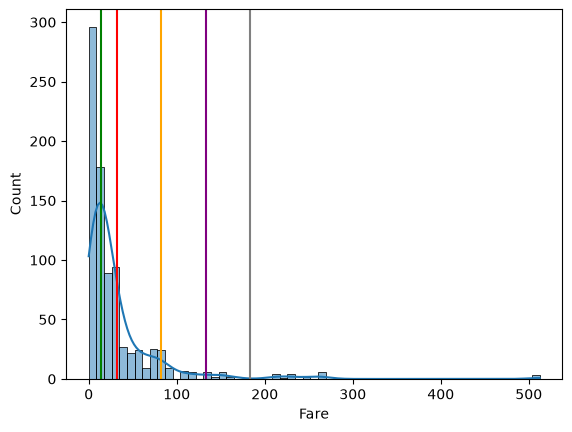

In [23]:
sns.histplot(data=df, x='Fare', kde=True)
plt.axvline(df['Fare'].mean(), color='red')
plt.axvline(df['Fare'].median(), color='green')
plt.axvline(df['Fare'].mean()+df['Fare'].std(), color='orange')
plt.axvline(df['Fare'].mean()+2*df['Fare'].std(), color='purple')
plt.axvline(df['Fare'].mean()+3*df['Fare'].std(), color='grey')

In [8]:
df['Fare'].mean() + df['Fare'].std()*3

np.float64(183.19672527531625)

# Its not logical in this data to fill the missing data with the End of Distribution but I am just doing it for learning purpose. 🙂

In [9]:
df.isnull().sum()

Fare        45
Family       0
Survived     0
dtype: int64

In [10]:
df['Fare'].mean()+3*df['Fare'].std()

np.float64(183.19672527531625)

In [11]:
df['Fare_'] = df['Fare'].fillna(df['Fare'].mean()+3*df['Fare'].std())

In [12]:
df.isnull().sum()

Fare        45
Family       0
Survived     0
Fare_        0
dtype: int64

<Axes: xlabel='Fare', ylabel='Count'>

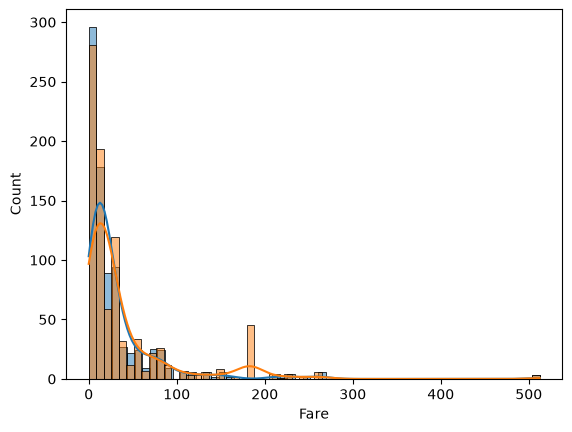

In [13]:
sns.histplot(data=df, x='Fare', kde=True)
sns.histplot(data=df, x='Fare_', kde=True)

In [24]:
std3 = df['Fare'].mean()+3*df['Fare'].std()

In [25]:
from sklearn.impute import SimpleImputer

In [27]:
obj = SimpleImputer(strategy='constant', fill_value=std3)

In [29]:
a= obj.fit_transform(df)

In [30]:
aa = pd.DataFrame(a, columns=df.columns)

In [32]:
aa.Fare.isnull().sum()

np.int64(0)

In [33]:
#Done!